## Multimodal Embeddings

**Introduction**

*Multimodal embeddings*, a powerful technique that bridges different data modalities such as text, images, audio, and even brain signals. Traditionally, AI research has focused on specific fields like Natural Language Processing (NLP) or computer vision. However, many real-world problems demand solutions that integrate multiple data types.

How multimodal embeddings, exemplified by models like CLIP, enable such integration, facilitating tasks like zero-shot image classification and image search. We will also examine the underlying techniques, especially contrastive learning, and practical applications, emphasizing their transformative potential.

---

### What Are Embeddings?

**Embeddings** are *numerical representations* of data learned through model training, capturing semantic or structural information. They serve as the foundation for many AI tasks.

| **Type of Data** | **Example** | **Representation** | **Purpose** |
|------------------|--------------|---------------------|--------------|
| Text             | Sentence or word | Vectors with dimensions | Capture semantic meaning, enable similarity comparisons |
| Images           | Photos, objects | Feature vectors | Recognize patterns, facilitate search and classification |
| Audio            | Sounds, speech | Audio feature vectors | Recognize sounds, match audio to text or images |

**Key Point:** Embeddings are *meaningful* in the sense that similar concepts are close in the embedding space, e.g., *"a cute puppy"* is near *"a good boy"* but far from *"funny cat meme"*.

---

### The Challenge of Cross-Modal Alignment

While embeddings work well within a single modality, **alignments across modalities** are non-trivial. For example, *text* and *images* have separate embedding spaces that are *not inherently aligned*. This misalignment prevents direct comparison or joint reasoning.

| **Text Embedding Space** | **Image Embedding Space** | **Issue** |  
|--------------------------|---------------------------|-----------|  
| Semantically meaningful | Semantically meaningful | No direct mapping |  
| Similar concepts close | Similar concepts close | But spaces are *not aligned* |  

*Example:* In text space, *"puppies"* might be in the top right, while in image space, *"puppies"* could be in a different region, making direct comparison ineffective.

---

### Multimodal Embeddings: The Solution

**Multimodal embeddings** aim to *align* different data modalities into a *shared vector space*. This allows, for example, *text* and *images* describing the same concept to be close together, enabling:

- **Zero-shot classification:** Recognizing objects without explicit training on specific classes.
- **Image search:** Finding images based on text queries.
- **Cross-modal retrieval:** Matching audio, brain signals, or other data types with images or text.

**Applications extend beyond images and text**, including audio, brain signals, and more.

---

### How Are Multimodal Embeddings Created?

The core technique is **contrastive learning**, which trains models to bring related data pairs closer and push unrelated pairs apart.

#### Contrastive Learning Process

- **Positive pairs:** Data that *belong together*, e.g., an image and its caption.
- **Negative pairs:** Data that *do not belong*, e.g., an image of a cat with a caption of a dog.

The model learns to **maximize similarity** for positive pairs and **minimize** for negative pairs.

---

### Mathematical Foundations

The process involves:

- Generating *embeddings* for each modality using encoders (e.g., image encoder, text encoder).
- Applying *learnable projection matrices* to map raw embeddings into a *shared space*.
- Computing *similarity scores* (often cosine similarity) between pairs.
- Using a **contrastive loss function** to optimize the model, encouraging positive pairs to have high similarity and negative pairs to have low similarity.

**Sample Loss Function:**

$$
\mathcal{L} = - \frac{1}{N} \sum_{i=1}^N \left[ \log \frac{\exp(\text{sim}(x_i, y_i)/\tau)}{\sum_{j=1}^N \exp(\text{sim}(x_i, y_j)/\tau)} + \log \frac{\exp(\text{sim}(x_i, y_i)/\tau)}{\sum_{j=1}^N \exp(\text{sim}(x_j, y_i)/\tau)} \right]
$$

Where:
- $\text{sim}(\cdot, \cdot)$ is the similarity measure.
- $\tau$ is a temperature parameter.
- $(x_i, y_i)$ are embeddings of paired data.

---

### Example Workflow with CLIP

| Step | Description |  
|-------|--------------|  
| 1 | Load images and text descriptions |  
| 2 | Encode images and texts into vectors |  
| 3 | Compute similarity scores (cosine similarity) |  
| 4 | Convert scores to probabilities via softmax |  
| 5 | Select the highest probability as the prediction |  

This process enables *flexible, zero-shot classification* and *search capabilities*.


---

### Practical Applications of Multimodal Embeddings

#### 1. **Zero-Shot Image Classification**

- **Goal:** Classify images into categories *without* training on those specific classes.
- **Method:**
  - Encode *text labels* describing classes.
  - Encode *images*.
  - Compute similarity scores.
  - Assign the class with the highest similarity.

**Example:**  
Class labels like *"a photo of a cat"* or *"a photo of a dog"* are encoded as text. When an image is processed, the model predicts the class based on which text label it aligns with most.

**Advantages:**
- No need for retraining for new classes.
- Highly flexible and adaptable.


In [1]:
# imports

from PIL import Image
from transformers import CLIPProcessor, CLIPModel

In [2]:
# functions


def classify_image(image, text_classes):
    """
    Helper function to do 0-shot image classfication with CLIP
    """

    # pass image and text classes to processor
    inputs = processor(
        text=text_classes, images=image, return_tensors="pt", padding=True
    )
    # pass inputs to CLIP
    outputs = model(**inputs)  # note: "**" unpacks dictionary items
    logits_per_image = outputs.logits_per_image  # image-text similarity score
    probs = logits_per_image.softmax(
        dim=1
    )  # convert scores to probabilties via softmax
    # prediction
    predicted_class = text_classes[probs.argmax()]
    prob_class = round(float(probs[0][probs.argmax()]), 4)

    return predicted_class, prob_class
  
def image_search(image_list, query):
    """
    Helper function to match query to an image in image_list
    """

    inputs = processor(text=query, images=image_list, return_tensors="pt", padding=True)
    outputs = model(**inputs)

    logits_per_text = outputs.logits_per_text
    probs = logits_per_text.softmax(dim=1)

    # best match
    best_match = image_list[probs.argmax()]
    prob_match = round(float(probs[0][probs.argmax()]), 4)

    return best_match, prob_match

#### Application 1: 0-shot Classification

In [3]:
# import model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")

# import processor (handles text tokenization and image preprocessing)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")


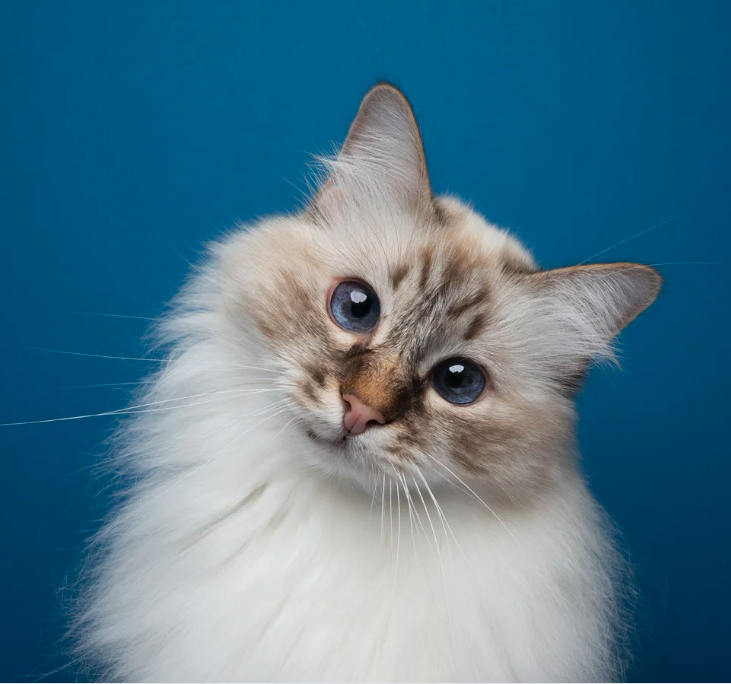

In [4]:
# load image
image = Image.open("./data/images/cat_cute.png")
image

In [5]:
# define text classes
text_classes = ["a photo of a cat", "a photo of a dog"]

# pass image and text classes to processor
inputs = processor(text=text_classes, images=image, return_tensors="pt", padding=True)

In [6]:
# pass inputs to CLIP
outputs = model(**inputs)  # note: "**" unpacks dictionary items
logits_per_image = outputs.logits_per_image  # image-text similarity score
probs = logits_per_image.softmax(dim=1)  # convert scores to probabilties via softmax

In [7]:
# print prediction
predicted_class = text_classes[probs.argmax()]
print(predicted_class, "| Probability = ", round(float(probs[0][probs.argmax()]), 4))

a photo of a cat | Probability =  0.9979


##### Cute VS Ugly

In [8]:
# define text classes
text_classes = ["ugly cat", "cute cat"]

predicted_class, prob_class = classify_image(image, text_classes)
print(predicted_class, "| Probability = ", prob_class)

cute cat | Probability =  0.9703


##### Meme VS Not Meme

In [9]:
# define text classes
text_classes = ["cat meme", "not cat meme"]

predicted_class, prob_class = classify_image(image, text_classes)
print(predicted_class, "| Probability = ", prob_class)

not cat meme | Probability =  0.5464


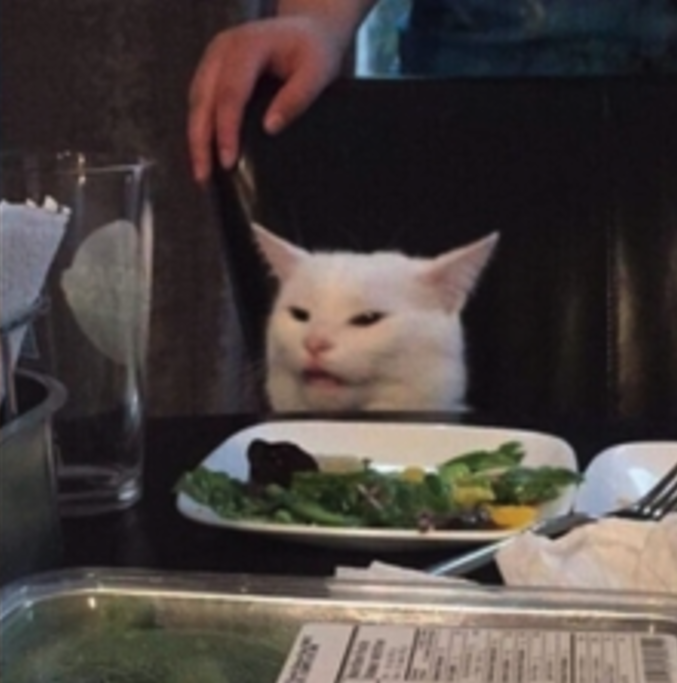

In [10]:
# load image
image = Image.open("./data/images/cat_meme.png")
image

In [11]:
predicted_class, prob_class = classify_image(image, text_classes)
print(predicted_class, "| Probability = ", prob_class)

cat meme | Probability =  0.8338


#### 2. **Image Search**

- **Goal:** Find images matching a text query.
- **Method:**
  - Encode all images into the shared space.
  - Encode the query text.
  - Compute similarity scores.
  - Retrieve the image with the highest score.

**Example:**  
Query: *"a cute dog"*. The model finds the most relevant image from a database.

In [12]:
# create list of images to search over
image_name_list = [
    "./data/images/cat_cute.png",
    "./data/images/dog.png",
    "./data/images/goat.png",
]

image_list = []
for image_name in image_name_list:
    image_list.append(Image.open(image_name))

In [13]:
# define a query
query = "a cute dog"

In [14]:
# pass images and query to CLIP
inputs = processor(text=query, images=image_list, return_tensors="pt", padding=True)
outputs = model(**inputs)
logits_per_text = outputs.logits_per_text
probs = logits_per_text.softmax(dim=1)

Match probability:  0.9817


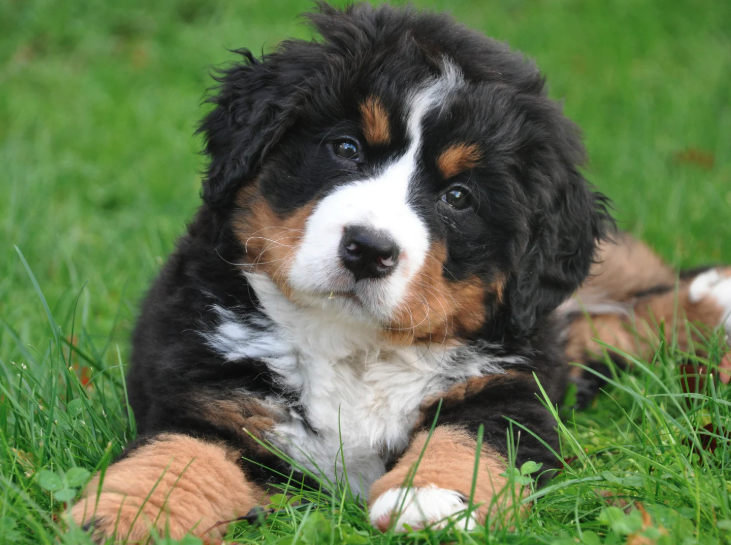

In [15]:
# print best match
best_match = image_list[probs.argmax()]
prob_match = round(float(probs[0][probs.argmax()]),4)

print("Match probability: ",prob_match)
display(best_match)

Match probability:  0.5664


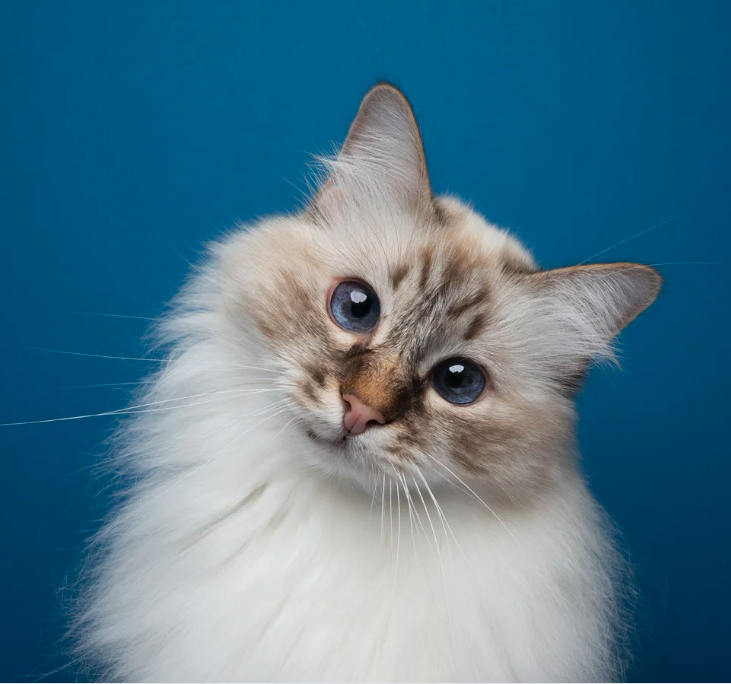

In [16]:
query = "the best pet in the world"

best_match, prob_match = image_search(image_list, query)

print("Match probability: ", prob_match)
display(best_match)


### **Conclusion**

Multimodal embeddings, exemplified by models like CLIP, unlock new possibilities in AI by bridging the gap between different data modalities. They enable *flexible, scalable, and powerful* applications such as zero-shot classification and cross-modal search, pushing the boundaries of what AI can achieve in understanding complex, real-world data. As research advances, these techniques will become even more integral to creating *intelligent, multi-sensory systems* capable of seamless integration across diverse data streams.

---